# Requirements

In [1]:
! pip install simpletransformers==0.63.11
! pip install transformers==4.30.2
! pip install emoji==2.4.0
! pip install contractions==0.1.73
! pip install twitter-text-parser==3.0.0

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 67.6 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 104.1 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 102.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.4/795.4 kB 95.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 85.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 100.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 103.5 MB/s  0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16250 sha256=23a485ca258c5595eb626c1a4e296ae8eb8e85fe8315446185d5efe65cf1e197
  Stored in directory: /home/baloni/.cach

In [1]:
import os
import json
import torch
import contractions
import pandas as pd
from tqdm import tqdm; tqdm.pandas()
from emoji import demojize
from nltk.tokenize import TweetTokenizer
from sklearn.model_selection import StratifiedKFold
from simpletransformers.classification import ClassificationModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from twitter_text import parse_tweet, extract_urls_with_indices, extract_emojis_with_indices
from collections import Counter
from spacy.lang.en import English
from transformers import AutoConfig

/home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/accelerate/utils/torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
ARGUMENT = 'Argument'
NOARGUMENT = 'No-Argument'

NONE = "None"
NOTIFICATION = "Notification"
STATEMENT = "Statement"
REASON = "Reason"

class2id = {REASON: 0, STATEMENT: 1, NOTIFICATION: 2, NONE: 3}
id2class = {v: k for k, v in class2id.items()}
category2id = {NOARGUMENT: 0, ARGUMENT: 1}

UNDECIDED = 'Undecided'

CV_OUTPUT = '/home/baloni/Perspective-Aware-KG/data/processed/bertweet_cv_predictions.csv'

# Data Preparation

In [3]:
# Pre-processing for BERTweets as required from the authors, taken from: https://github.com/VinAIResearch/BERTweet/blob/master/TweetNormalizer.py
tokenizer = TweetTokenizer()

def normalizeToken(token):
    lowercased_token = token.lower()
    if token.startswith("@"):
        return "@USER"
    elif lowercased_token.startswith("http") or lowercased_token.startswith("www"):
        return "HTTPURL"
    elif len(token) == 1:
        return demojize(token)
    else:
        if token == "’":
            return "'"
        elif token == "…":
            return "..."
        else:
            return contractions.fix(token) # Change in code, the original version does not resolve all contractions

def normalizeTweet(tweet):
    tokens = tokenizer.tokenize(tweet.replace("’", "'").replace("…", "..."))
    normTweet = " ".join([normalizeToken(token) for token in tokens])

    normTweet = (
        normTweet.replace("cannot ", "can not ")
        .replace("n't ", " n't ")
        .replace("n 't ", " n't ")
        .replace("ca n't", "can't")
        .replace("ai n't", "ain't")
    )
    normTweet = (
        normTweet.replace("'m ", " 'm ")
        .replace("'re ", " 're ")
        .replace("'s ", " 's ")
        .replace("'ll ", " 'll ")
        .replace("'d ", " 'd ")
        .replace("'ve ", " 've ")
    )
    normTweet = (
        normTweet.replace(" p . m .", "  p.m.")
        .replace(" p . m ", " p.m ")
        .replace(" a . m .", " a.m.")
        .replace(" a . m ", " a.m ")
    )

    return " ".join(normTweet.split())

In [4]:
df_majority = pd.read_csv('/home/baloni/Perspective-Aware-KG/data/TACO/majority_votes.csv', index_col='tweet_id', keep_default_na=False, na_values=[''])
df_backup = pd.read_csv('/home/baloni/Perspective-Aware-KG/data/TACO/backup_tweets.csv', index_col='tweet_id', lineterminator='\n')

df_majority = df_majority[df_majority['class'] != UNDECIDED].copy()
df_majority['class'] = df_majority['class'].replace(class2id)
df_majority = df_majority.merge(right=df_backup, on='tweet_id')
df_majority['text'] = df_majority.progress_apply(lambda row: normalizeTweet(row.text), axis=1)

/tmp/ipykernel_472518/2301550156.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_majority['class'] = df_majority['class'].replace(class2id)
100%|██████████| 1734/1734 [00:00<00:00, 6053.51it/s]


# Cross-Validation

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import torch
import accelerate
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base", use_fast=False)
skf = StratifiedKFold(n_splits=10, random_state=123456789, shuffle=True)

df_predictions = pd.DataFrame()

for fold, (train_idx, test_idx) in enumerate(skf.split(df_majority, df_majority['class'])):
    print(f"Starting fold {fold+1}/10")

    df_train = df_majority.iloc[train_idx]
    df_test = df_majority.iloc[test_idx]

    train_dataset = TweetDataset(
        df_train["text"].tolist(),
        df_train["class"].tolist(),
        tokenizer
    )

    test_dataset = TweetDataset(
        df_test["text"].tolist(),
        df_test["class"].tolist(),
        tokenizer
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        "vinai/bertweet-base",
        num_labels=4
    )

    training_args = TrainingArguments(
        output_dir=f"/home/baloni/Perspective-Aware-KG/data/baseline_models/cv_fold_{fold}",
        num_train_epochs=5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=4e-5,
        logging_steps=50,
        save_strategy="no",
        evaluation_strategy="no",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset
    )

    trainer.train()

    save_path = f"/home/baloni/Perspective-Aware-KG/data/baseline_models/cv_fold_{fold}"
    trainer.model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)


    preds = trainer.predict(test_dataset).predictions
    preds = preds.argmax(axis=1)

    df_test = df_test.copy()
    df_test["class_pred"] = preds
    df_predictions = pd.concat([df_predictions, df_test[["class", "class_pred"]]])

df_predictions = df_predictions.sort_index()
df_predictions.to_csv(CV_OUTPUT)



/home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
/home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Starting fold 1/10


Some weights of the model checkpoint at vinai/bertweet-base were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.weight', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight', 'lm_head.decoder.bias', 'lm_head.decoder.weight', 'roberta.pooler.dense.bias', 'lm_head.dense.weight', 'lm_head.dense.bias', 'lm_head.bias']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: 

Step,Training Loss
50,0.826500
100,0.551500
150,0.397400
200,0.275700


Starting fold 2/10


/home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at vinai/bertweet-base were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.weight', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight', 'lm_head.decoder.bias', 'lm_head.decoder.weight', 'roberta.pooler.dense.bias', 'lm_head.dense.weight', 'lm_head.dense.bias', 'lm_head.bias']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification f

Step,Training Loss
50,0.842200
100,0.590100
150,0.431600
200,0.334900


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:73                                                                                   │
│                                                                                                  │
│   70 │   │   train_dataset=train_dataset                                                         │
│   71 │   )                                                                                       │
│   72 │                                                                                           │
│ ❱ 73 │   trainer.train()                                                                         │
│   74 │                                                                                           │
│   75 │   save_path = f"/home/baloni/Perspective-Aware-KG/data/baseline_models/cv_fold_{fold}"    │
│   76 │   trainer.model.save_pretrained(save_path)                                                │
│                                                                                                  │
│ /home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/transformers/trainer.py:16 │
│ 64 in train                                                                                      │
│                                                                                                  │
│   1661 │   │   inner_training_loop = find_executable_batch_size(                                 │
│   1662 │   │   │   self._inner_training_loop, self._train_batch_size, args.auto_find_batch_size  │
│   1663 │   │   )                                                                                 │
│ ❱ 1664 │   │   return inner_training_loop(                                                       │
│   1665 │   │   │   args=args,                                                                    │
│   1666 │   │   │   resume_from_checkpoint=resume_from_checkpoint,                                │
│   1667 │   │   │   trial=trial,                                                                  │
│                                                                                                  │
│ /home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/transformers/trainer.py:19 │
│ 40 in _inner_training_loop                                                                       │
│                                                                                                  │
│   1937 │   │   │   │   │   with model.no_sync():                                                 │
│   1938 │   │   │   │   │   │   tr_loss_step = self.training_step(model, inputs)                  │
│   1939 │   │   │   │   else:                                                                     │
│ ❱ 1940 │   │   │   │   │   tr_loss_step = self.training_step(model, inputs)                      │
│   1941 │   │   │   │                                                                             │
│   1942 │   │   │   │   if (                                                                      │
│   1943 │   │   │   │   │   args.logging_nan_inf_filter                                           │
│                                                                                                  │
│ /home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/transformers/trainer.py:27 │
│ 53 in training_step                                                                              │
│                                                                                                  │
│   2750 │   │   │   # loss gets scaled under gradient_accumulation_steps in deepspeed             │
│   2751 │   │   │   loss = self.deepspeed.backward(loss)                                          │
│   2752 │   │   else:                                                                             │
│ ❱ 2753 │   │   │   loss.backward()                         

# Evaluation

In [7]:
df_validation = pd.read_csv(CV_OUTPUT)
df_validation = df_validation.set_index('tweet_id')

assert sorted(df_majority.index) == sorted(df_validation.index)
assert sorted(df_validation.index) == sorted(df_majority.index)

for tweet_id in df_majority.index:
    assert df_majority.loc[tweet_id]['class'] == df_validation.loc[tweet_id]['class']

df_validation = df_validation.merge(df_backup, on=['tweet_id'])

y_true = df_validation['class'].to_list()
y_pred = df_validation['class_pred'].to_list()

y_true_bin = [y in [class2id[REASON], class2id[STATEMENT]] for y in y_true]
y_pred_bin = [y in [class2id[REASON], class2id[STATEMENT]] for y in y_pred]

In [8]:
# binary classification evaluation
print(classification_report(y_true_bin, y_pred_bin, target_names=category2id.keys(), digits=4))

              precision    recall  f1-score   support

 No-Argument     0.8618    0.8251    0.8430       869
    Argument     0.8315    0.8671    0.8489       865

    accuracy                         0.8460      1734
   macro avg     0.8466    0.8461    0.8460      1734
weighted avg     0.8467    0.8460    0.8460      1734



In [9]:
# multi-class classification evaluation
print(classification_report(y_true, y_pred, target_names=class2id.keys(), digits=4))

              precision    recall  f1-score   support

      Reason     0.7302    0.7917    0.7597       581
   Statement     0.5625    0.5387    0.5504       284
Notification     0.7748    0.7500    0.7622       500
        None     0.8161    0.7696    0.7922       369

    accuracy                         0.7336      1734
   macro avg     0.7209    0.7125    0.7161      1734
weighted avg     0.7339    0.7336    0.7330      1734



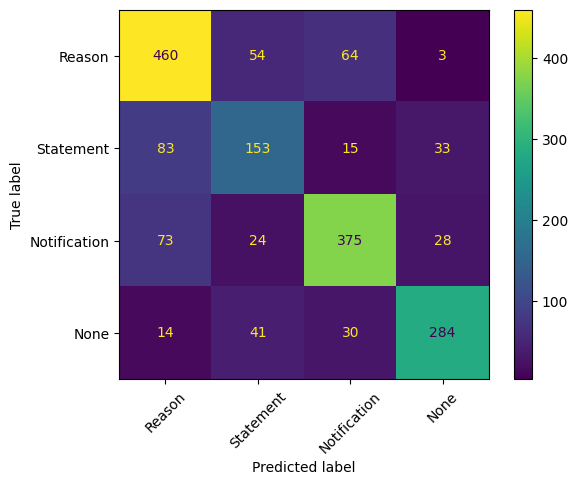

In [10]:
# y_true is a 1D array of true class labels, and y_pred is a 1D array of predicted class labels
cm = confusion_matrix(y_true, y_pred)

# display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class2id.keys())
disp.plot(xticks_rotation=45)

In [11]:
# error tracing
with open('./data/url_dict.json') as json_file:
    url_dict = json.load(json_file)

def add_information(df):
    df = df.copy()
    nlp = English()

    def process_url(tweet_text, lookup):
        urls = extract_urls_with_indices(tweet_text)
        has_external_url = any('twitter.com' not in url_dict.get(url['url'], None) for url in urls)
        return int(has_external_url)

    def process_emojis(tweet_text):
        return len(extract_emojis_with_indices(tweet_text)) > 0

    def detect_discourse_markers(text):
        discourse_markers = ["actually", "anyway", "basically", "certainly", "clearly", "consequently", "definitely", "evidently",
                     "generally", "however", "incidentally", "indeed", "interestingly", "likewise", "meanwhile", "moreover",
                     "nevertheless", "obviously", "overall", "personally", "previously", "really", "right", "so", "somehow",
                     "sometimes", "specifically", "still", "technically", "therefore", "thus", "unfortunately", "well", "whatever",
                     "whenever", "whereas", "whether", "while", "yet"]
        doc = nlp(text)
        markers = []
        for token in doc:
            if token.lower_ in discourse_markers:
                markers.append(token.lower_)
        return markers

    df['length'] = df.progress_apply(lambda row: parse_tweet(row.text).weightedLength, axis=1)
    df['urls'] = df.progress_apply(lambda row: len(extract_urls_with_indices(row.text)), axis=1)
    df['has_external_url'] = df.progress_apply(lambda row: process_url(row.text, url_dict), axis=1)
    df['emojis'] = df.progress_apply(lambda row: len(extract_emojis_with_indices(row.text)), axis=1)
    df['hashtags'] = df.progress_apply(lambda row: Counter(row.text).get('#', 0), axis=1)
    df['users'] = df.progress_apply(lambda row: Counter(row.text).get('@', 0), axis=1)
    df['marker'] = df.progress_apply(lambda row: len(detect_discourse_markers(row.text)), axis=1)

    return df

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:2                                                                                    │
│                                                                                                  │
│    1 # error tracing                                                                             │
│ ❱  2 with open('./data/url_dict.json') as json_file:                                             │
│    3 │   url_dict = json.load(json_file)                                                         │
│    4                                                                                             │
│    5 def add_information(df):                                                                    │
│                                                                                                  │
│ /home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/IPython/core/interactivesh │
│ ell.py:324 in _modified_open                                                                     │
│                                                                                                  │
│    321 │   │   │   "you can use builtins' open."                                                 │
│    322 │   │   )                                                                                 │
│    323 │                                                                                         │
│ ❱  324 │   return io_open(file, *args, **kwargs)                                                 │
│    325                                                                                           │
│    326 class InteractiveShell(SingletonConfigurable):                                            │
│    327 │   """An enhanced, interactive shell for Python."""                                      │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
FileNotFoundError: [Errno 2] No such file or directory: './data/url_dict.json'

In [ ]:
df_missclassification = add_information(df_validation[(df_validation['class'] == class2id[STATEMENT]) &
                                       (
                                           (df_validation['class_pred'] == class2id[REASON]) |
                                           (df_validation['class_pred'] == class2id[NOTIFICATION])
                                       )])

In [ ]:
df_statement = add_information(df_validation[df_validation['class'] == class2id[STATEMENT]])
print("\nCharacteristics class Statement:")
print("Mean Length:", df_statement['length'].describe()['mean'])
print(" % urls > 0:", round(100*(df_statement[df_statement.urls > 0].shape[0]/df_statement.shape[0]), 2))
print("     % external > 0:", round(100*(df_statement[(df_statement.urls > 0) & (df_statement.has_external_url > 0)].shape[0]/df_statement[df_statement.urls > 0].shape[0]), 2))
print(" % marker > 0:", round(100*(df_statement[df_statement.marker > 0].shape[0]/df_statement.shape[0]), 2))


print("Miss-classifications for class Statement:")
print("Mean Length:", df_missclassification['length'].describe()['mean'])
print(" % urls > 0:", round(100*(df_missclassification[df_missclassification.urls > 0].shape[0]/df_missclassification.shape[0]), 2))
print("     % external > 0:", round(100*(df_missclassification[(df_missclassification.urls > 0) & (df_missclassification.has_external_url > 0)].shape[0]/df_missclassification[df_missclassification.urls > 0].shape[0]), 2))
print(" % marker > 0:", round(100*(df_missclassification[df_missclassification.marker > 0].shape[0]/df_missclassification.shape[0]), 2))

100%|██████████| 284/284 [00:00<00:00, 458.93it/s]



Characteristics class Statement:
Mean Length: 121.63028169014085
 % urls > 0: 8.1
     % external > 0: 17.39
 % marker > 0: 19.01
Miss-classifications for class Statement:
Mean Length: 171.8139534883721
 % urls > 0: 22.09
     % external > 0: 15.79
 % marker > 0: 24.42


# Retraining

In [ ]:
final_model_name = "TACO"
model_args["output_dir"] = f"./model/{final_model_name}"
model_args["no_save"] = False

In [ ]:
if not os.path.exists(model_args["output_dir"]):
    simple_transformer = ClassificationModel('bertweet',
                                             'vinai/bertweet-base',
                                             use_cuda=torch.cuda.is_available(),
                                             num_labels=4,
                                             args=model_args)

    df_train = df_majority[['text', 'class']].copy()
    df_train = df_train.sample(frac=1, random_state=123456789)
    simple_transformer.train_model(df_train)

    config=AutoConfig.from_pretrained(model_args["output_dir"])
    config.label2id = class2id
    config.id2label = id2class
    config.save_pretrained(model_args["output_dir"])